<a href="https://colab.research.google.com/github/anjalikumari6246/Weather-Forcast/blob/main/Daily_Climate_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Load the dataset

In [2]:
# Load the dataset
data = pd.read_csv('DailyDelhiClimateTrain.csv')

## Dataset Overview

In [3]:
# Display the first few rows
data.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,01-01-2013,10.000000,84.500000,0.000000,1015.666667
1,02-01-2013,7.400000,92.000000,2.980000,1017.800000
2,03-01-2013,7.166667,87.000000,4.633333,1018.666667
3,04-01-2013,8.666667,71.333333,1.233333,1017.166667
4,05-01-2013,6.000000,86.833333,3.700000,1016.500000


In [4]:
# Display the data types and missing values
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1575 entries, 0 to 1574
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1575 non-null   str    
 1   meantemp      1575 non-null   float64
 2   humidity      1575 non-null   float64
 3   wind_speed    1575 non-null   float64
 4   meanpressure  1575 non-null   float64
dtypes: float64(4), str(1)
memory usage: 61.7 KB


In [5]:
# Display summary statistics
data.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1575.000000,1575.000000,1575.000000,1575.000000
mean,25.231582,60.420115,6.903642,1010.589745
std,7.337316,16.956083,4.508803,175.298310
min,6.000000,13.428571,0.000000,-3.041667
25%,18.516667,49.750000,3.700000,1001.875000
50%,27.166667,62.380952,6.370000,1009.000000
75%,31.142857,72.125000,9.262500,1015.183334
max,38.714286,98.000000,42.220000,7679.333333


## Data Cleaning

In [6]:
# Dataset Shape
print("Rows and Columns:", data.shape)

Rows and Columns: (1575, 5)


In [7]:
# Column Names
print(data.columns)

Index(['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure'], dtype='str')


In [8]:
if data.isnull().sum().sum() == 0:
    print("No missing values found.")
else:
    data.ffill(inplace=True)

No missing values found.


In [9]:
# Convert the 'date' column to datetime format
data['date'] = pd.to_datetime(data['date'], format='%d-%m-%Y')

## EDA

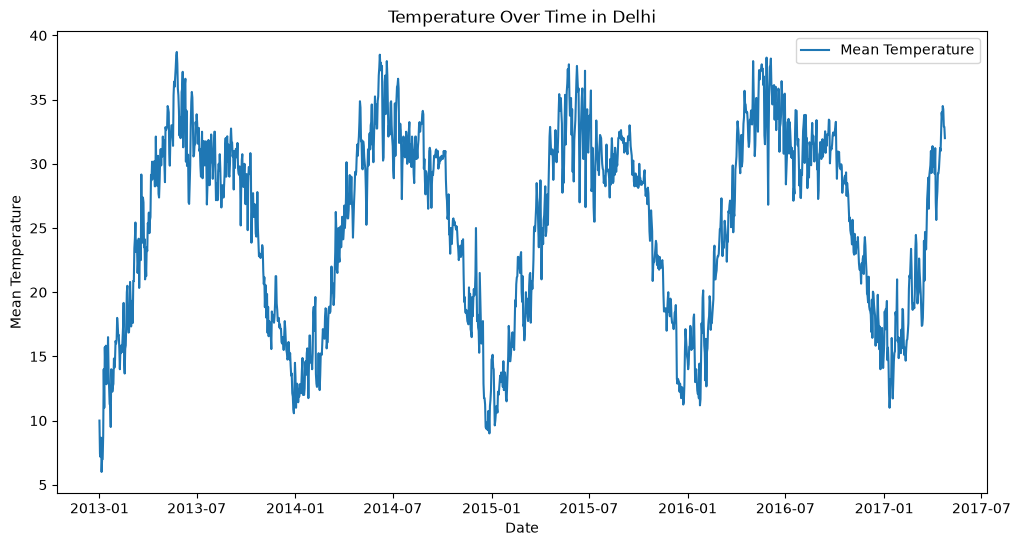

In [10]:
# Plot temperature over time
plt.figure(figsize=(12,6))
plt.plot(data['date'], data['meantemp'], label='Mean Temperature')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.title('Temperature Over Time in Delhi')
plt.legend()
plt.show()

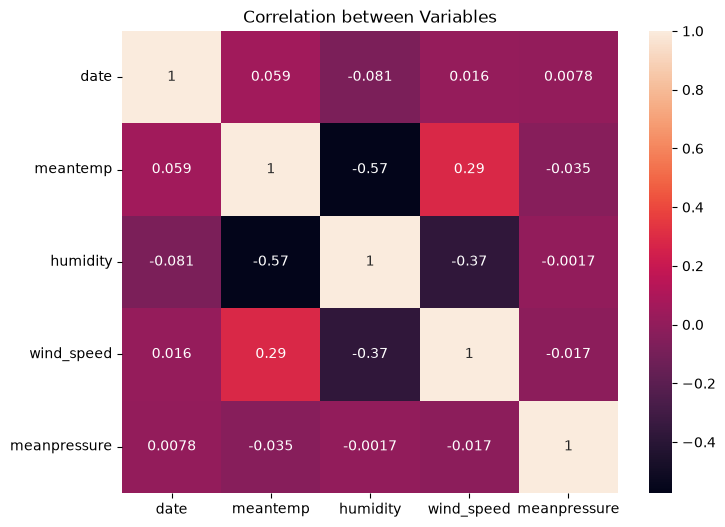

In [11]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True)
plt.title('Correlation between Variables')
plt.show()

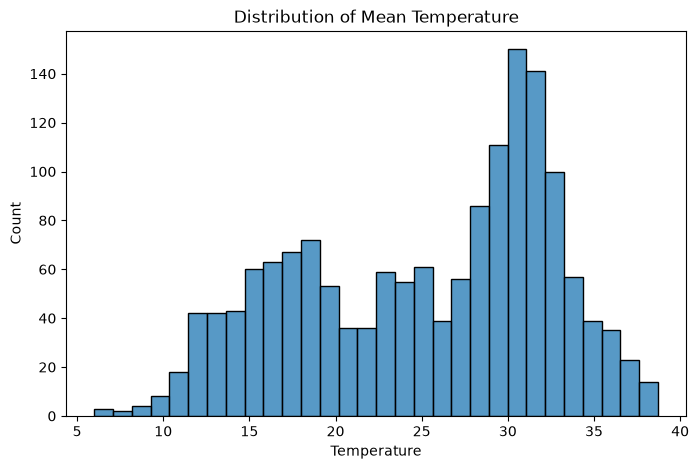

In [12]:
#Temprature distribution
plt.figure(figsize=(8,5))
sns.histplot(data['meantemp'], bins=30)
plt.title("Distribution of Mean Temperature")
plt.xlabel("Temperature")
plt.show()

## Feature Engineering

In [13]:
# Extract year, month, and day from the date
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day

# Create lag features
data['meantemp_lag1'] = data['meantemp'].shift(1)

# Create rolling mean for temperature
data['meantemp_roll_mean'] = data['meantemp'].rolling(window=7).mean()

# Drop rows with NaN values created by lag/rolling
data.dropna(inplace=True)

print(data.columns)

Index(['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure', 'year',
       'month', 'day', 'meantemp_lag1', 'meantemp_roll_mean'],
      dtype='str')


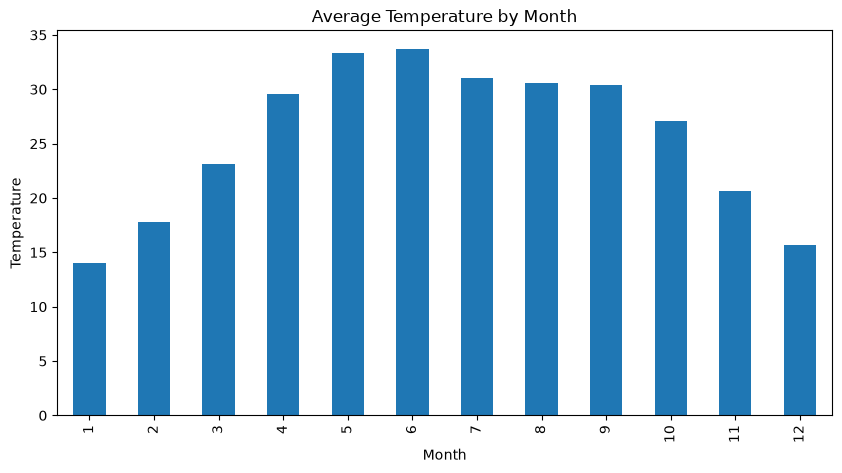

In [14]:
#Monthly Average Temperature
monthly_temp = data.groupby('month')['meantemp'].mean()

plt.figure(figsize=(10,5))
monthly_temp.plot(kind='bar')
plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

## Machine Learning

In [15]:
# Define features and target variable
features = ['humidity', 'wind_speed', 'meanpressure', 'meantemp_lag1', 'meantemp_roll_mean']
target = 'meantemp'

# Split data into training and testing sets
X = data[features]
y = data[target]

print(X.shape)
print(y.shape)

(1569, 5)
(1569,)


In [16]:
X.head()

,humidity,wind_speed,meanpressure,meantemp_lag1,meantemp_roll_mean
6,78.600000,6.300000,1020.000000,7.000000,7.604762
7,63.714286,7.142857,1018.714286,7.000000,7.441497
8,51.250000,12.500000,1017.000000,8.857143,8.384354
9,62.000000,7.400000,1015.666667,14.000000,8.931973
10,51.285714,10.571429,1016.142857,11.000000,9.938776


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## Model Evaluation

In [18]:
# Predict temperatures on the test set
y_pred = model.predict(X_test)

# Create predictions DataFrame
predictions = pd.DataFrame({
    'Date': data['date'].iloc[-len(y_test):].values,
    'Actual_Temperature': y_test.values,
    'Predicted_Temperature': y_pred
})

# Save to CSV
predictions.to_csv('predictions.csv', index=False)

print("predictions.csv created successfully!")

predictions.csv created successfully!


In [19]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = model.score(X_test, y_test)

print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'R-squared Score: {r2:.2f}')

Mean Absolute Error: 1.09
Root Mean Squared Error: 1.38
R-squared Score: 0.96


## Feature Importance

In [20]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.to_csv('feature_importance.csv', index=False)

print(feature_importance)

              Feature  Importance
3       meantemp_lag1    0.526148
4  meantemp_roll_mean    0.440881
0            humidity    0.019038
2        meanpressure    0.008904
1          wind_speed    0.005029


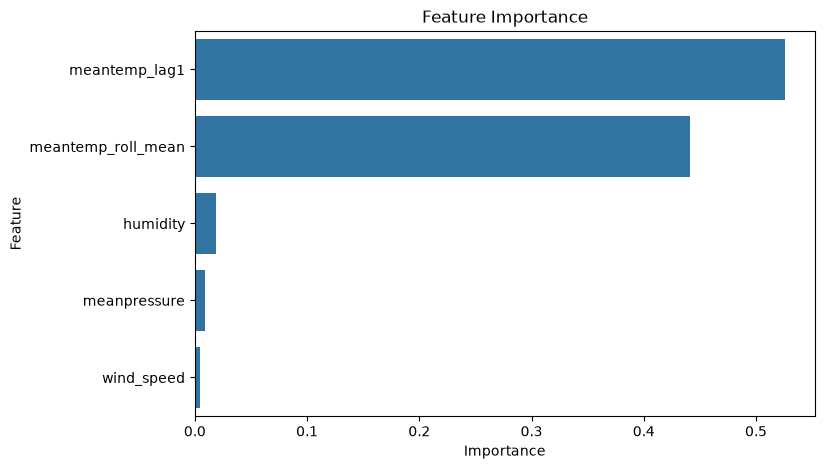

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()

## Actual vs Predicted Temperature

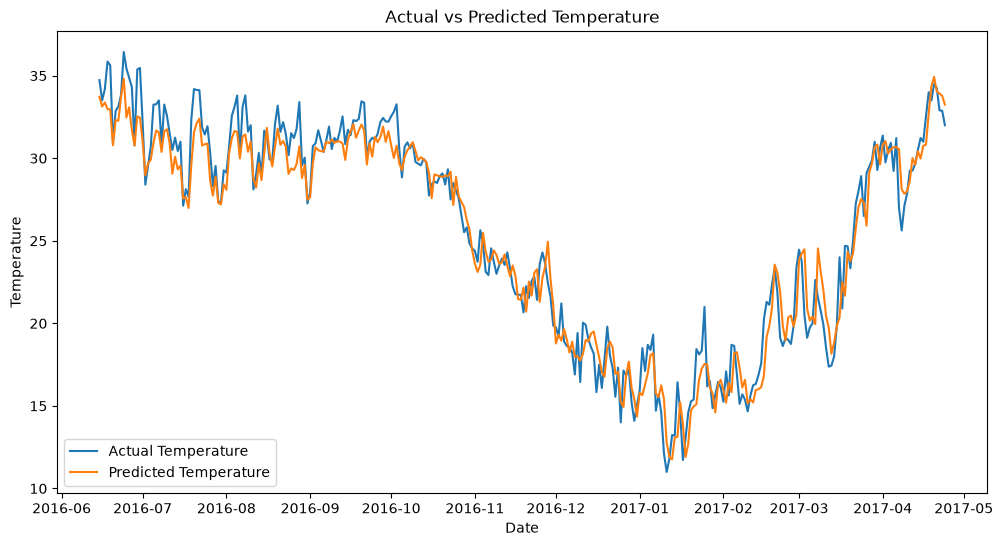

In [23]:
# Plot actual vs predicted temperatures
plt.figure(figsize=(12,6))
plt.plot(data['date'][-len(y_test):], y_test, label='Actual Temperature')
plt.plot(data['date'][-len(y_test):], y_pred, label='Predicted Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Actual vs Predicted Temperature')
plt.legend()
plt.show()


## Export the cleaned dataset

In [26]:
# Save the cleaned dataset for SQL and Power BI
data.to_csv("weather_cleaned2.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
